# Transfer Learning with TensorFlow Feature Extraction Models

### There are two main benefits to using **transfer learning**:

1. We can leverage an existing neural network architecture proven to work on problems similar to our own.
2. We can leverage a working neural network architecture which has already learned patterns on similar data to our own. This often results in achieving great results with less custom data.

In [1]:
# Are we using a GPU?

!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
# !pip install tensorflow==2.14 tensorflow-hub==0.15   # Need to install these versions so that everything works

### Load the data (10% of 10 food classes)

In [3]:
import tensorflow as tf
import zipfile
import os


In [4]:

# Download data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

# Unzip the downloaded file
zip_ref = zipfile.ZipFile("10_food_classes_10_percent.zip", "r")
zip_ref.extractall()
zip_ref.close()

--2025-03-03 00:01:39--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.206.207, 108.177.121.207, 209.85.145.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.206.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip.3’

10_food_classes_10_ 100%[===================>] 160.74M   149MB/s    in 1.1s    

2025-03-03 00:01:40 (149 MB/s) - ‘10_food_classes_10_percent.zip.3’ saved [168546183/168546183]



### Let's examine the downloaded food data...

In [5]:
for dirpath, dirnames, filenames in os.walk("10_food_classes_10_percent"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/train'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/steak'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_wings'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_curry'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/pizza'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/hamburger'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/fried_rice'.
There are 0 directories and 75 images in '10_food_classes_10_percent

### So we only have 10% (i.e., 75) of the original training data of 750 images of each food class.



### We will use the `ImageDataGenerator` class to load in the images in batches.

In [6]:
# Setup data inputs
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SHAPE = (224, 224)
BATCH_SIZE = 32

train_dir = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

In [7]:
IMAGE_SHAPE + (3,)

(224, 224, 3)

In [8]:

print("Training images:")
train_data_10_percent = train_datagen.flow_from_directory(train_dir,
                                               target_size=IMAGE_SHAPE,
                                               batch_size=BATCH_SIZE,
                                               class_mode="categorical")

print("Testing images:")
test_data = train_datagen.flow_from_directory(test_dir,
                                              target_size=IMAGE_SHAPE,
                                              batch_size=BATCH_SIZE,
                                              class_mode="categorical")

Training images:
Found 750 images belonging to 10 classes.
Testing images:
Found 2500 images belonging to 10 classes.


**Callbacks** are extra functionality that can be added to models to be performed during or after training. Some of the most popular callbacks include:

1. **Experiment tracking with TensorBoard** - log the performance of multiple models and then view and compare these models in a visual way on TensorBoard (a dashboard for inspecting neural network parameters). Helpful to compare the results of different models on your data.
2. **Model checkpointing** - save the model as it trains so you can stop training if needed and come back to continue off where you left. Helpful if training takes a long time and can't be done in one sitting.
3. **Early stopping** - leave the model training for an arbitrary amount of time and have it stop training automatically when it ceases to improve. Helpful when you've got a large dataset and don't know how long training will take.

### Let's create a TensorBoard Callback to save the model run results to a file.

In [9]:
import datetime

def create_tensorboard_callback(dir_name, experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback

### Creating models using TensorFlow Hub

In the past, we've used TensorFlow to create our own models and build them layer by layer from scratch.  

Now, we are going to perform a similar process except that the majority of our model's layers are going to come from TensorFlow Hub.

We can access pre-trained models on https://tfhub.dev.

So, we are looking for a good, trained image classification model.  `ResNet` and `EfficientNet` are great candidates for this type of use case.

After browsing the TensorFlow Hub site and filtering on 'image classification' use cases, we found the following feature vector model links:

[EfficientNet-V2](https://www.kaggle.com/models/tensorflow/efficientnet/TensorFlow2/b0-feature-vector/1)

[ResNet-V2](https://www.kaggle.com/models/google/resnet-v2/TensorFlow2/50-feature-vector/2)

Let's compare the performance of these two models!


In [10]:
# Import dependencies

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Input # import Input
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
def create_and_compile_model(model_url, num_classes=10):
  """
  Takes a TensorFlow Hub URL and creates a Keras Sequential model with it.

  Args:
    model_url (str): A TensorFlow Hub feature extraction URL.
    num_classes (int): Number of output neurons in output layer,
      should be equal to number of target classes, default 10.

  Returns:
    An uncompiled Keras Sequential model with model_url as feature
    extractor layer and Dense output layer with num_classes outputs.

  """
  model = tf.keras.Sequential([
        hub.KerasLayer(model_url,
                   trainable=False,
                   name='feature_extraction_layer',
                   input_shape=IMAGE_SHAPE+(3,)),
        tf.keras.layers.Dense(num_classes,
                              activation='softmax',
                              name='softmax_layer')
  ])


  # Compile the model
  model.compile(loss='categorical_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

  return model

In [12]:
resnet_url = "https://www.kaggle.com/models/google/resnet-v2/TensorFlow2/50-feature-vector/2"
efficientnet_url = "https://www.kaggle.com/models/tensorflow/efficientnet/TensorFlow2/b0-feature-vector/1"

### Let's start with the `ResNet` feature extraction model.

In [13]:
# Create model
resnet_model = create_and_compile_model(resnet_url, num_classes=train_data_10_percent.num_classes)
resnet_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feature_extraction_layer (  (None, 2048)              23564800  
 KerasLayer)                                                     
                                                                 
 softmax_layer (Dense)       (None, 10)                20490     
                                                                 
Total params: 23585290 (89.97 MB)
Trainable params: 20490 (80.04 KB)
Non-trainable params: 23564800 (89.89 MB)
_________________________________________________________________


In [14]:
# Fit the model on the training data

resnet_model_history = resnet_model.fit(train_data_10_percent,
                                        epochs=5,
                                        steps_per_epoch=len(train_data_10_percent),
                                        validation_data = test_data,
                                        validation_steps = len(test_data),
                                        callbacks=[create_tensorboard_callback("tensorflow_hub", "resnet_V2_model")])

Saving TensorBoard log files to: tensorflow_hub/resnet_V2_model/20250303-000215
Epoch 1/5
24/24 [==============================] - 545s 23s/step - loss: 1.8586 - accuracy: 0.3773 - val_loss: 1.1643 - val_accuracy: 0.6368
Epoch 2/5
24/24 [==============================] - 530s 23s/step - loss: 0.8949 - accuracy: 0.7373 - val_loss: 0.8562 - val_accuracy: 0.7244
Epoch 3/5
24/24 [==============================] - 522s 23s/step - loss: 0.5986 - accuracy: 0.8253 - val_loss: 0.7397 - val_accuracy: 0.7644
Epoch 4/5
24/24 [==============================] - 562s 24s/step - loss: 0.4600 - accuracy: 0.9013 - val_loss: 0.6947 - val_accuracy: 0.7796
Epoch 5/5
24/24 [==============================] - 530s 23s/step - loss: 0.3683 - accuracy: 0.9213 - val_loss: 0.6677 - val_accuracy: 0.7836


### Let's plot the loss curves for the model

In [16]:
# If you wanted to, you could really turn this into a helper function to load in with a helper.py script...
import matplotlib.pyplot as plt

# Plot the validation and training data separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

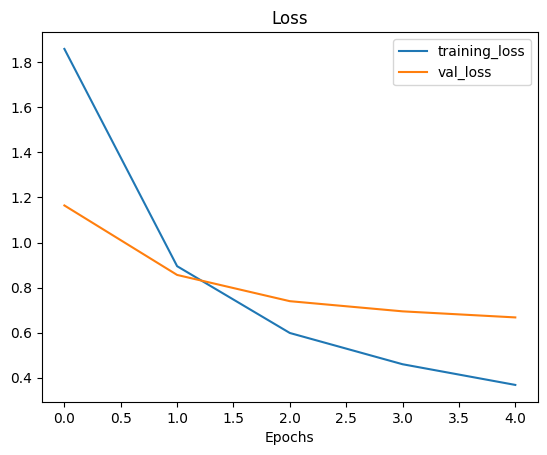

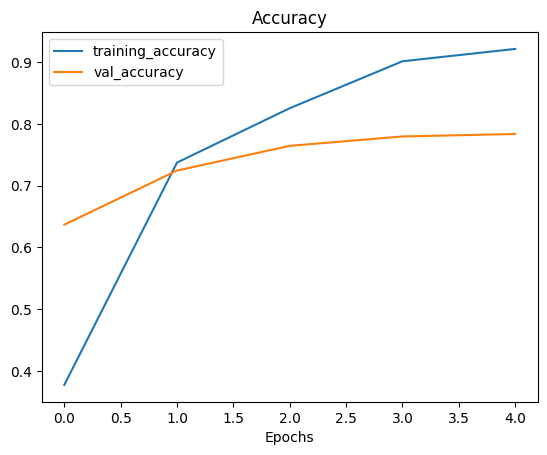

In [17]:
plot_loss_curves(resnet_model_history)

### Now, let's train the EfficientNet model

In [19]:
# Create model
efficientnet_model = create_and_compile_model(efficientnet_url, num_classes=train_data_10_percent.num_classes)
efficientnet_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feature_extraction_layer (  (None, 1280)              4049564   
 KerasLayer)                                                     
                                                                 
 softmax_layer (Dense)       (None, 10)                12810     
                                                                 
Total params: 4062374 (15.50 MB)
Trainable params: 12810 (50.04 KB)
Non-trainable params: 4049564 (15.45 MB)
_________________________________________________________________


In [20]:
# Fit the model on the training data

efficientnet_model_history = efficientnet_model.fit(train_data_10_percent,
                                        epochs=5,
                                        steps_per_epoch=len(train_data_10_percent),
                                        validation_data = test_data,
                                        validation_steps = len(test_data),
                                        callbacks=[create_tensorboard_callback("tensorflow_hub", "efficientnet_V2_model")])

Saving TensorBoard log files to: tensorflow_hub/efficientnet_V2_model/20250303-005246
Epoch 1/5
24/24 [==============================] - 247s 10s/step - loss: 1.8503 - accuracy: 0.4600 - val_loss: 1.2847 - val_accuracy: 0.7272
Epoch 2/5
24/24 [==============================] - 252s 11s/step - loss: 1.0675 - accuracy: 0.7680 - val_loss: 0.8646 - val_accuracy: 0.8208
Epoch 3/5
24/24 [==============================] - 214s 9s/step - loss: 0.7659 - accuracy: 0.8253 - val_loss: 0.6979 - val_accuracy: 0.8444
Epoch 4/5
24/24 [==============================] - 214s 9s/step - loss: 0.6210 - accuracy: 0.8600 - val_loss: 0.6075 - val_accuracy: 0.8576
Epoch 5/5
24/24 [==============================] - 224s 10s/step - loss: 0.5206 - accuracy: 0.8880 - val_loss: 0.5549 - val_accuracy: 0.8632


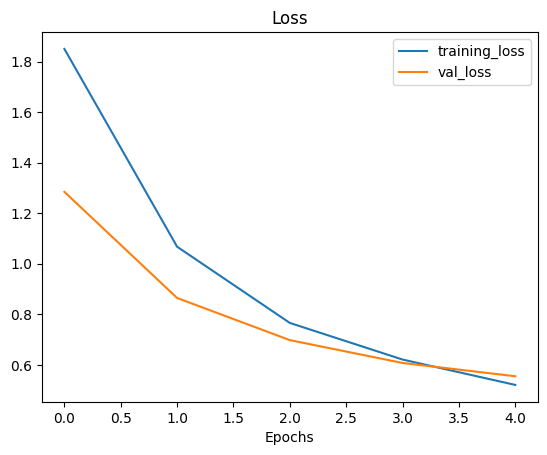

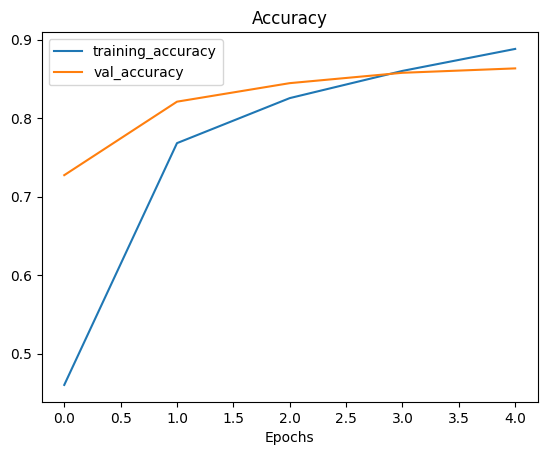

In [21]:
plot_loss_curves(efficientnet_model_history)

In [24]:
# Load the TensorBoard notebook extension
%load_ext tensorboard